In [1]:
nb_id = 80

In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
import ipywidgets as widgets
from IPython.display import display

import mesa_reader as mr

In [3]:
%matplotlib inline
plt.style.use('./plotstyle.mplstyle')

In [14]:
GRID = Path('/gpfs/lsdf02/sd23g011/desa/ceph/mesa_che_grids/sse_dbg_production/00_fiducial/0002_ZdivZsun_2d-02/010_m60/fine_vct_tdc_mtf')
FIGURE_FOLDER = Path(f'./output/nb{nb_id}/figures')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

In [15]:
# Build a pandas index of the grid: one row per completed run, with whichever
# control-variation axes this grid varies (full names) and final-value diagnostics.
# Works for both the coarse grid (vct/tdc/mtf/mjd/cfl/cflh) and the fine grid
# (vct/tdc/mtf only, over a different set of values) since it discovers the
# axes present in each directory name rather than assuming a fixed set.
CONTROL_NAMES = {
    'vct': 'varcontrol_target',
    'tdc': 'time_delta_coeff',
    'mtf': 'maximum_timestep_factor',
    'mjd': 'min_J_div_delta_J',
    'cfl': 'dt_div_min_dr_div_cs_limit',
    'cflh': 'dt_div_min_dr_div_cs_hard_limit',
}
TOKEN_RE = re.compile(r'^([a-zA-Z]+)([0-9]+(?:p[0-9]+)?)$')

def parse_dirname(name):
    """vct1_tdc1p0_mtf1p1_mjd15_cfl0p7_cflh0p85 -> {full_name: float value}.
    Returns None if any token isn't a recognized control axis (e.g. 'template',
    'LOGS'), so it doubles as a filter for non-run directories."""
    controls = {}
    for token in name.split('_'):
        m = TOKEN_RE.match(token)
        if m is None or m.group(1) not in CONTROL_NAMES:
            return None
        controls[CONTROL_NAMES[m.group(1)]] = float(m.group(2).replace('p', '.'))
    return controls

dirs = sorted(d for d in GRID.iterdir() if d.is_dir() and parse_dirname(d.name) is not None)

histories = {}
records = []
for d in dirs:
    hist_path = d / 'LOGS' / 'history.data'
    if not hist_path.exists():
        continue
    try:
        h = mr.MesaData(str(hist_path))
    except Exception as e:
        print(f'Skip {d.name}: {e}')
        continue
    histories[d] = h
    record = {'path': d, **parse_dirname(d.name)}
    record['center_h1'] = h.data('center_h1')[-1]
    record['center_he4'] = h.data('center_he4')[-1]
    record['center_c12'] = h.data('center_c12')[-1]
    record['center_o16'] = h.data('center_o16')[-1]
    record['logTeff'] = h.data('log_Teff')[-1]
    record['model_number'] = h.data('model_number')[-1]
    record['dt'] = 10 ** (h.data('log_dt')[-1]) / 3.156e7  # yr
    records.append(record)

index_df = pd.DataFrame(records)
index_df

,path,varcontrol_target,time_delta_coeff,maximum_timestep_factor,center_h1,center_he4,center_c12,center_o16,logTeff,model_number,dt
0,/gpfs/lsdf02/sd23g011/desa/ceph/mesa_che_grids...,1.0,1.0,1.100,4.071795e-02,9.589585e-01,0.000007,1.022192e-06,4.170691,1063,1.853587e-23
1,/gpfs/lsdf02/sd23g011/desa/ceph/mesa_che_grids...,1.0,1.0,1.325,3.777065e-02,9.619063e-01,0.000006,1.450698e-06,3.947533,3962,3.105777e-14
2,/gpfs/lsdf02/sd23g011/desa/ceph/mesa_che_grids...,1.0,1.0,1.550,0.000000e+00,4.479934e-12,0.121020,8.097155e-01,3.870244,3043,4.372922e-24
3,/gpfs/lsdf02/sd23g011/desa/ceph/mesa_che_grids...,1.0,1.0,1.775,2.990010e-26,9.995248e-01,0.000135,9.431174e-07,4.635867,3015,1.456703e-15
4,/gpfs/lsdf02/sd23g011/desa/ceph/mesa_che_grids...,1.0,1.0,2.000,3.975170e-02,9.599245e-01,0.000007,9.997047e-07,4.275950,2343,2.596587e-14
...,...,...,...,...,...,...,...,...,...,...,...
120,/gpfs/lsdf02/sd23g011/desa/ceph/mesa_che_grids...,3.0,1.5,1.100,0.000000e+00,2.702595e-12,0.126971,8.100830e-01,3.923293,1804,3.929078e-29
121,/gpfs/lsdf02/sd23g011/desa/ceph/mesa_che_grids...,3.0,1.5,1.325,3.133274e-02,9.683418e-01,0.000007,9.192779e-07,4.577409,2665,2.440660e-16
122,/gpfs/lsdf02/sd23g011/desa/ceph/mesa_che_grids...,3.0,1.5,1.550,0.000000e+00,2.894452e-12,0.131783,8.082983e-01,3.864921,2138,4.518266e-22
123,/gpfs/lsdf02/sd23g011/desa/ceph/mesa_che_grids...,3.0,1.5,1.775,0.000000e+00,4.477341e-21,0.000079,7.436357e-01,5.180663,1662,1.430033e-27


In [16]:
# Panel grid = (varcontrol_target rows) x (maximum_timestep_factor columns),
# color = time_delta_coeff. Sized from whatever values index_df actually has,
# so this works unchanged for the coarse grid (2x2 panels, 2 tdc colors) and
# the fine grid (5x5 panels, 5 tdc colors).
vct_values = sorted(index_df.varcontrol_target.unique())
mtf_values = sorted(index_df.maximum_timestep_factor.unique())
tdc_values = sorted(index_df.time_delta_coeff.unique())

nrows, ncols = len(vct_values), len(mtf_values)
panel_order = [(vct, mtf) for vct in vct_values for mtf in mtf_values]

def panel_label(key):
    vct, mtf = key
    return f'varcontrol_target={vct:g}, max_timestep_factor={mtf:g}'

def panel_rows(key):
    """Rows of index_df for a given (varcontrol_target, maximum_timestep_factor) panel."""
    vct, mtf = key
    return index_df[(index_df.varcontrol_target == vct) & (index_df.maximum_timestep_factor == mtf)]

tdc_cmap = plt.cm.viridis
tdc_norm = plt.Normalize(vmin=min(tdc_values), vmax=max(tdc_values))

def color_for_row(row):
    """Color by time_delta_coeff value, via a colormap so it scales to any number of levels."""
    return tdc_cmap(tdc_norm(row.time_delta_coeff))

def alpha_for_row(row):
    return 0.5

def add_tdc_colorbar(fig, axes):
    sm = ScalarMappable(cmap=tdc_cmap, norm=tdc_norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, label='time_delta_coeff', ticks=tdc_values)

### HR diagram

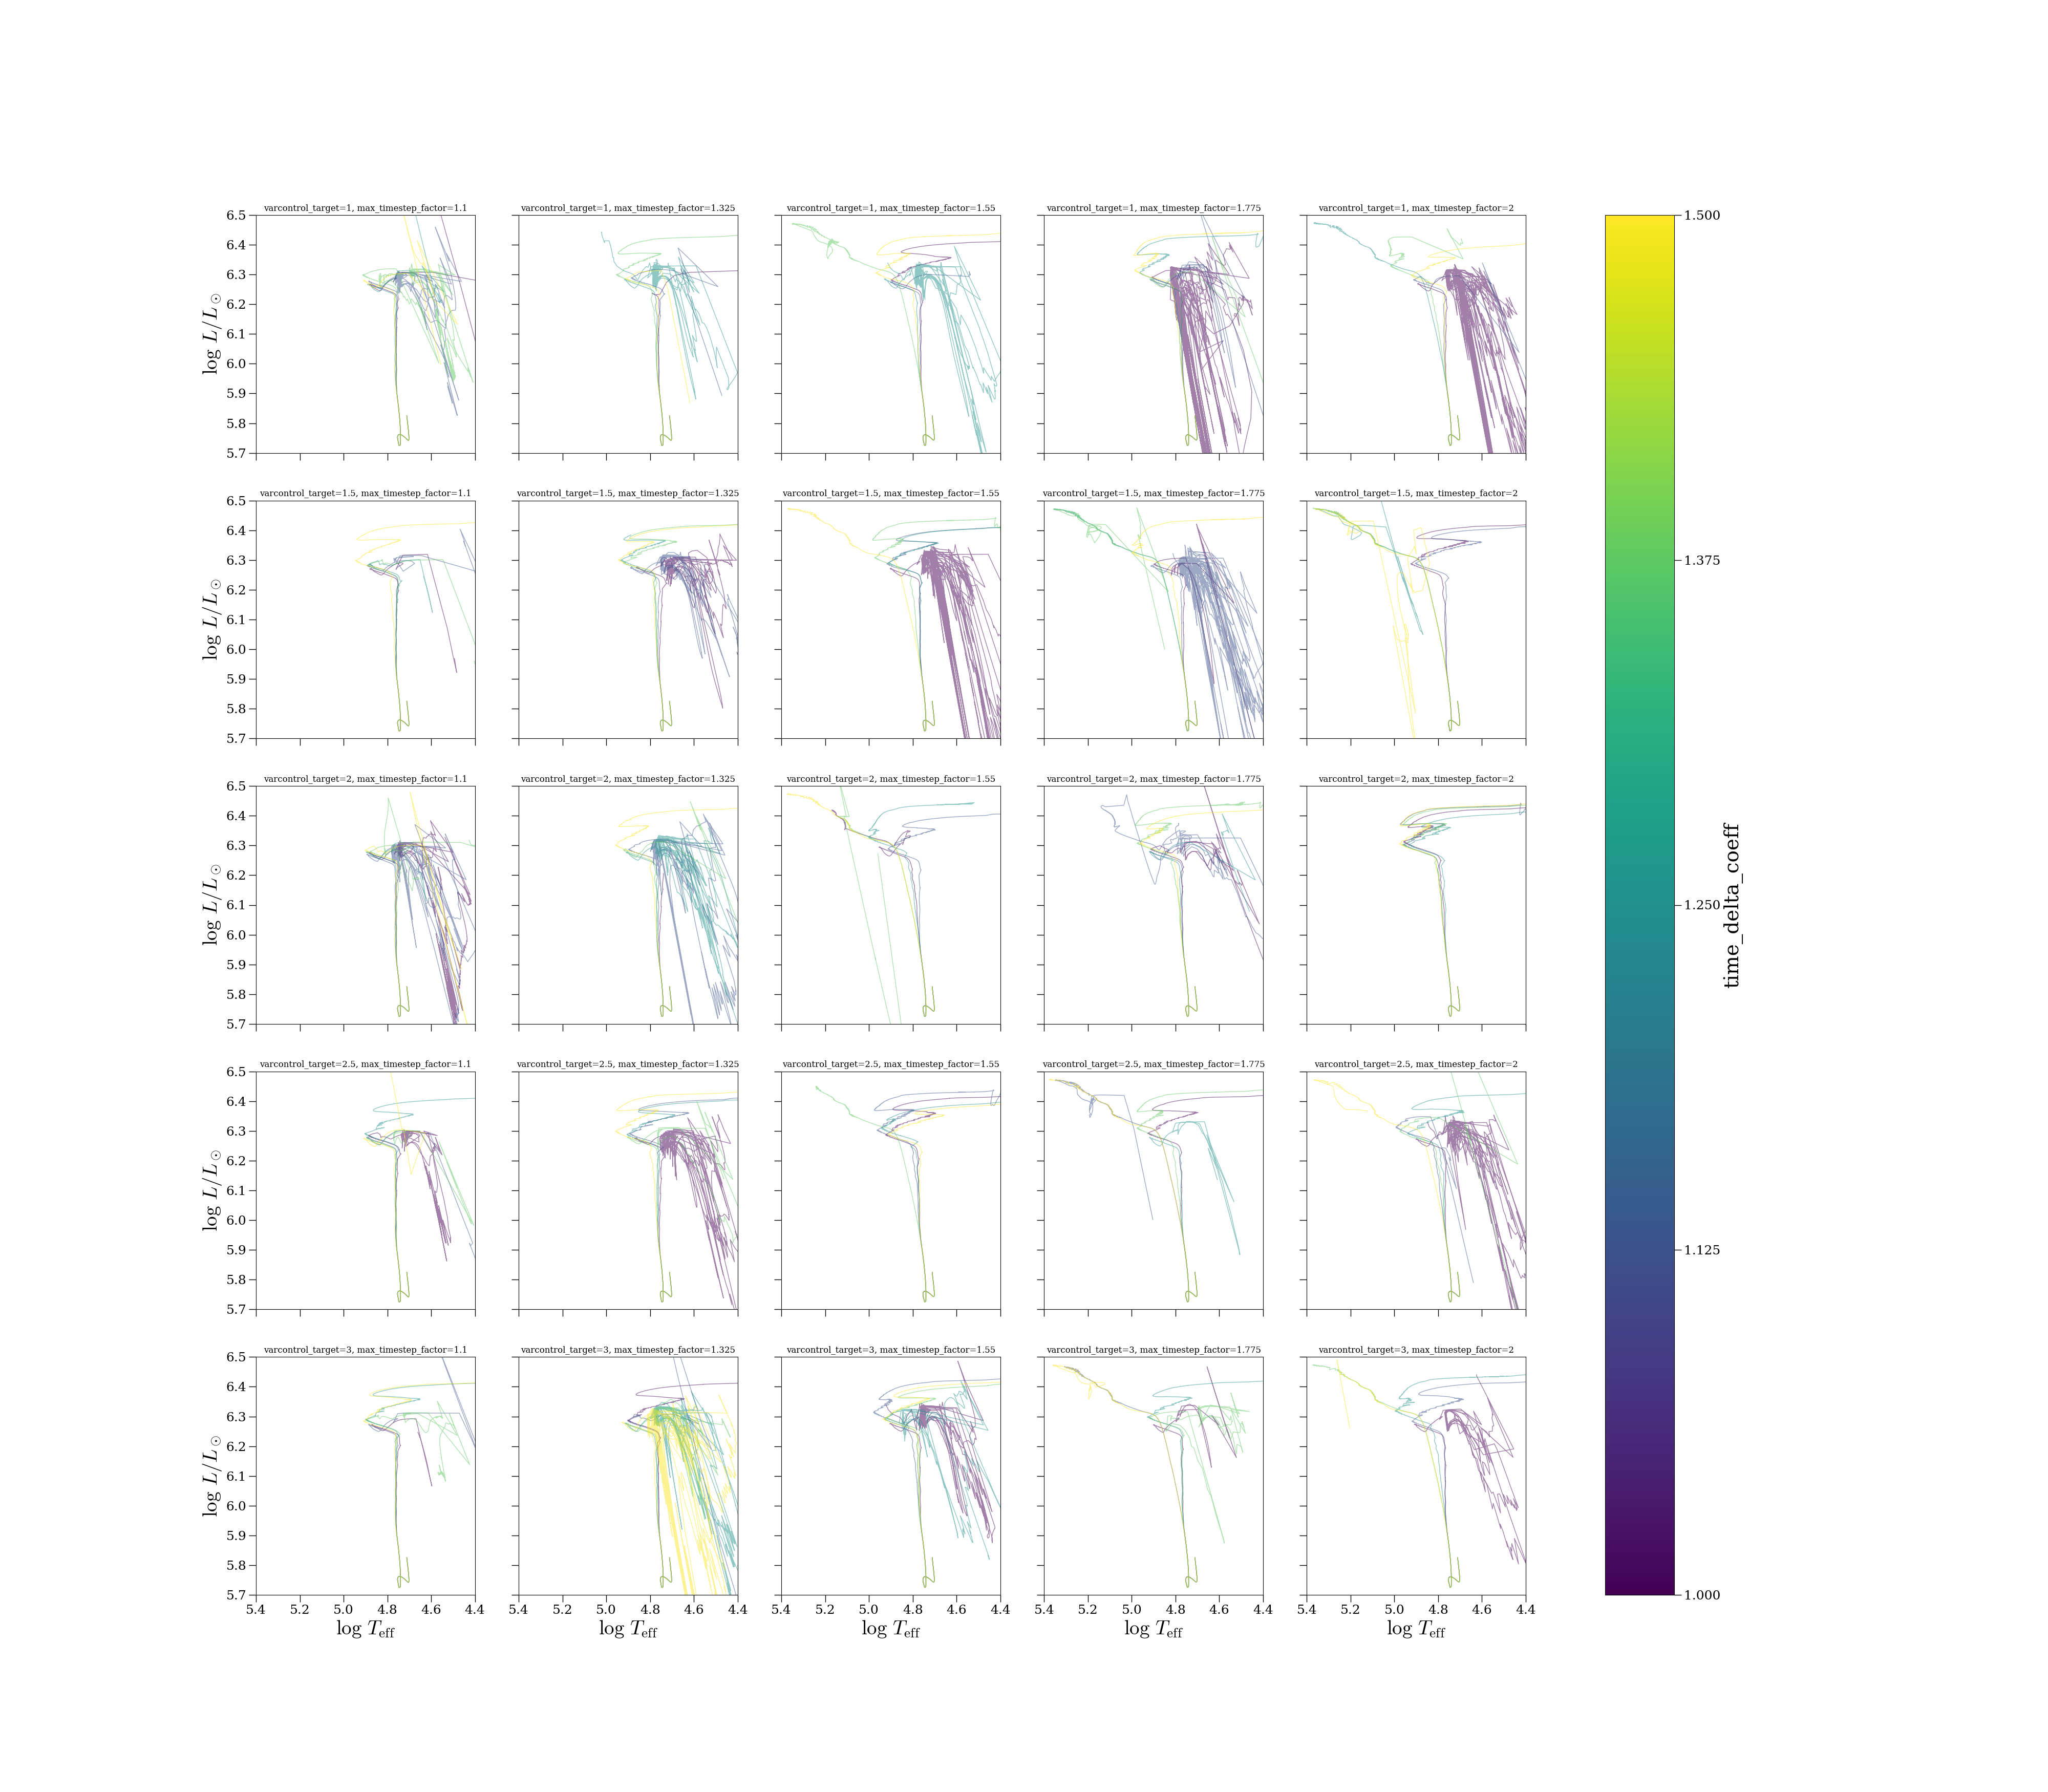

In [17]:
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 7 * nrows), sharex=True, sharey=True, squeeze=False)

for ax, key in zip(axes.flat, panel_order):
    for _, row in panel_rows(key).iterrows():
        h = histories[row.path]
        ax.plot(h.data('log_Teff'), h.data('log_L'),
                color=color_for_row(row), alpha=alpha_for_row(row), lw=1)
    ax.set_title(panel_label(key), fontsize=12)
    ax.invert_xaxis()

for ax in axes[-1, :]:
    ax.set_xlabel(r'$\log\,T_{\rm eff}$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\log\,L/L_\odot$')

axes[0, 0].set_xlim(5.4, 4.4)
axes[0, 0].set_ylim(5.7, 6.5)

add_tdc_colorbar(fig, axes)
fig.savefig(FIGURE_FOLDER / 'hrd.pdf', bbox_inches='tight')

### Timestep evolution

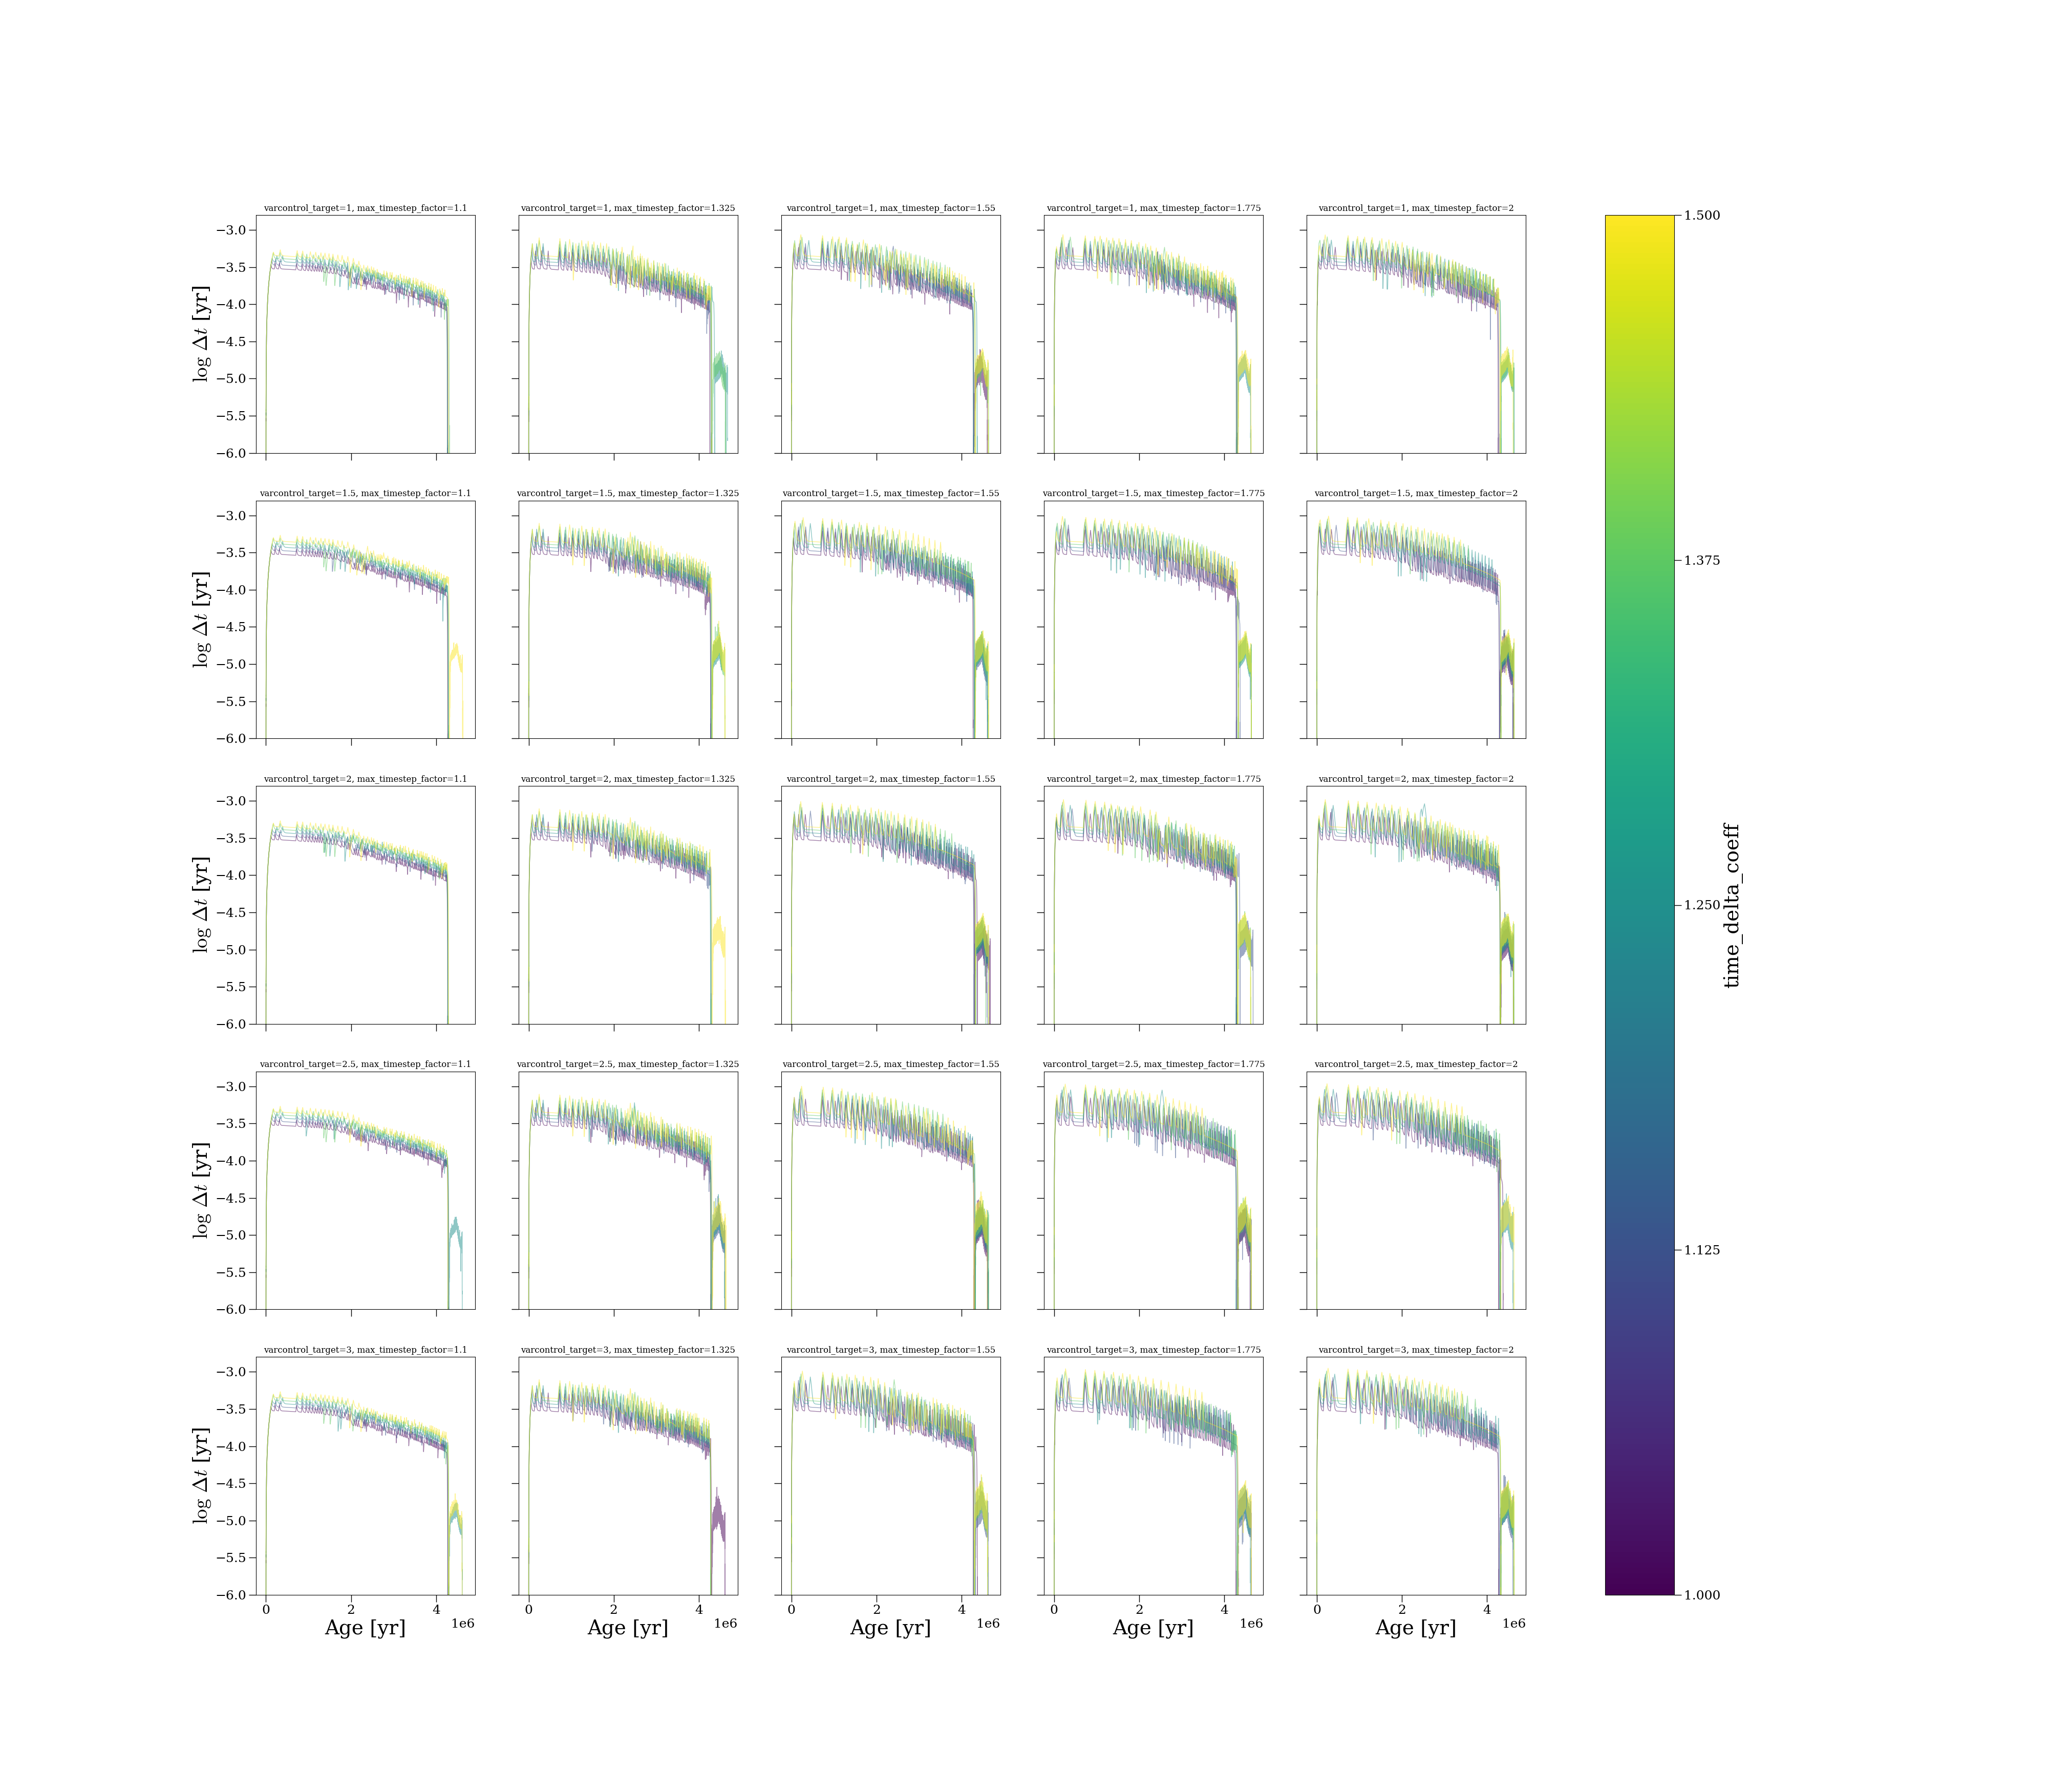

In [18]:
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 7 * nrows), sharex=True, sharey=True, squeeze=False)

for ax, key in zip(axes.flat, panel_order):
    for _, row in panel_rows(key).iterrows():
        h = histories[row.path]
        age = h.data('star_age')
        ax.plot(age, h.data('log_dt') - np.log10(3.156e7),
                color=color_for_row(row), alpha=alpha_for_row(row), lw=1)
    ax.set_title(panel_label(key), fontsize=12)
    ax.axhline(-10, color='k', ls=':', lw=0.8, alpha=0.4)

for ax in axes[-1, :]:
    ax.set_xlabel(r'Age [yr]')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\log\,\Delta t$ [yr]')

axes[0,0].set_ylim(-6, -2.8)
add_tdc_colorbar(fig, axes)
fig.savefig(FIGURE_FOLDER / 'timestep.pdf', bbox_inches='tight')

### $v / c_s$ max evolution

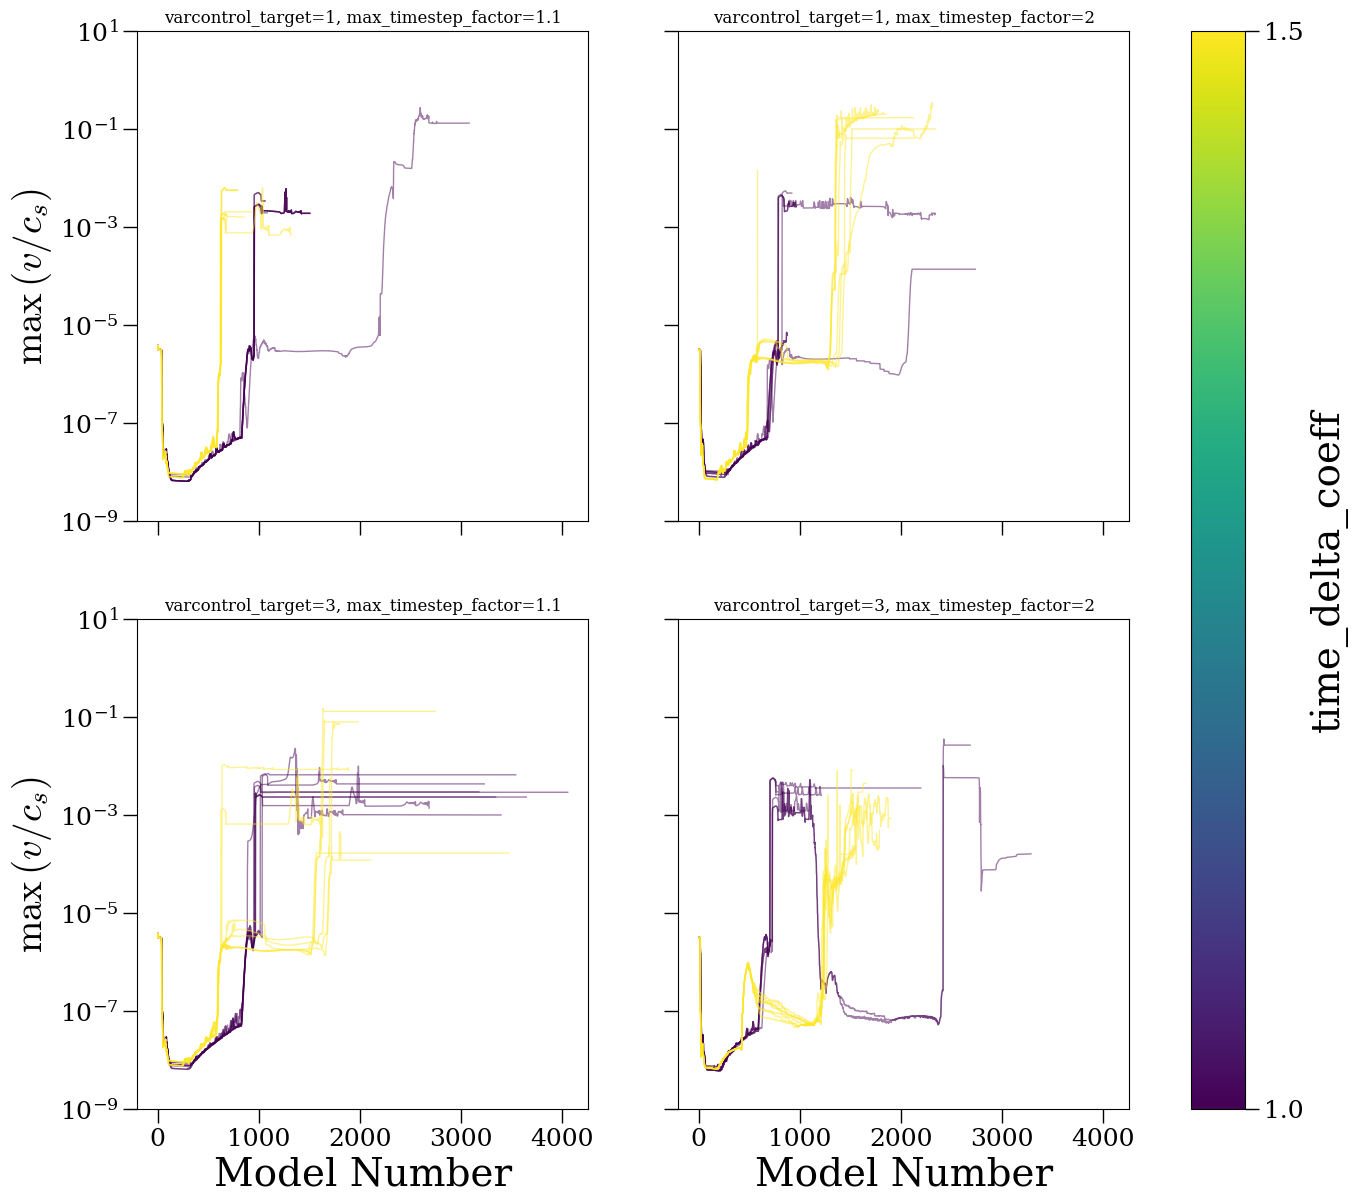

In [9]:
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 7 * nrows), sharex=True, sharey=True, squeeze=False)

for ax, key in zip(axes.flat, panel_order):
    for _, row in panel_rows(key).iterrows():
        h = histories[row.path]
        age = h.data('model_number')
        vcs = h.data('v_div_csound_max')
        ax.semilogy(age, np.clip(vcs, 1e-10, None),
                    color=color_for_row(row), alpha=alpha_for_row(row), lw=1)
    ax.set_title(panel_label(key), fontsize=12)
    ax.set_ylim(1e-10, 1e1)

for ax in axes[-1, :]:
    ax.set_xlabel(r'Model Number')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\max\,(v/c_s)$')

axes[0,0].set_ylim(1e-9, )
#axes[0,0].set_xscale('log')
add_tdc_colorbar(fig, axes)
fig.savefig(FIGURE_FOLDER / 'v_div_cs.pdf', bbox_inches='tight')

### Profile explorer

Set `TRACK_NAMES` (run directory names under `GRID`), `X_VAR`, and `Y_VAR` below, then scrub through the saved profiles with the slider. Uses `%matplotlib widget` so dragging the slider updates the existing line in place instead of re-rendering a static image each tick.

In [10]:
def list_profiles(run_dir):
    """Sorted (model_number, profile_number) pairs from a run's profiles.index."""
    idx_path = run_dir / 'LOGS' / 'profiles.index'
    if not idx_path.exists():
        return []
    with open(idx_path) as f:
        lines = f.readlines()[1:]  # skip header
    return sorted(
        (int(parts[0]), int(parts[2]))
        for parts in (line.split() for line in lines if line.strip())
    )

def load_profile(run_dir, profile_number):
    prof_path = run_dir / 'LOGS' / f'profile{profile_number}.data'
    if not prof_path.exists():
        return None
    return mr.MesaData(str(prof_path))

CONTROL_COLUMNS = [c for c in CONTROL_NAMES.values() if c in index_df.columns]

def model_label(row):
    return ', '.join(f'{c}={row[c]:g}' for c in CONTROL_COLUMNS)

In [11]:
# --- Pick tracks & variables here ---
TRACK_NAMES = ['vct1_tdc1p0_mtf1p1_mjd15_cfl0p7_cflh0p85']  # dir names under GRID; add more to overplot
X_VAR = 'logtau'
Y_VAR = 'velocity'

In [12]:
%matplotlib widget

tracks = {name: GRID / name for name in TRACK_NAMES}
for name, run_dir in tracks.items():
    assert run_dir in histories, f'{name}: not a completed run under the current GRID'

def preload_profiles(run_dir, x_var, y_var):
    loaded = []
    for model_number, profile_number in list_profiles(run_dir):
        prof = load_profile(run_dir, profile_number)
        if prof is None:
            continue
        loaded.append({'model_number': model_number, 'x': prof.data(x_var), 'y': prof.data(y_var)})
    return loaded

track_profiles = {name: preload_profiles(run_dir, X_VAR, Y_VAR) for name, run_dir in tracks.items()}
track_ages = {
    name: dict(zip(histories[run_dir].data('model_number'), histories[run_dir].data('star_age')))
    for name, run_dir in tracks.items()
}
n_profiles = max(len(profs) for profs in track_profiles.values())

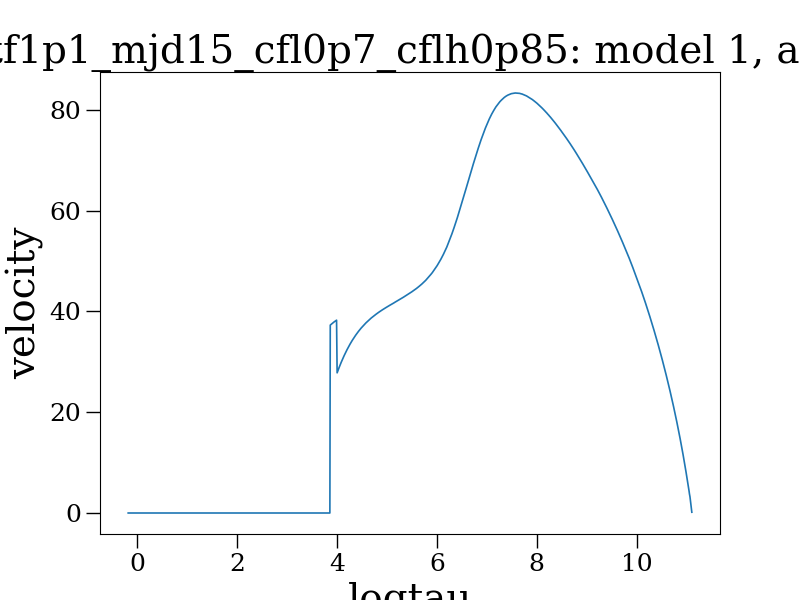

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

lines = {}
for name, run_dir in tracks.items():
    prof0 = track_profiles[name][0]
    (line,) = ax.plot(prof0['x'], prof0['y'], lw=1.2, label=name)
    lines[name] = line

ax.set_xlabel(X_VAR)
ax.set_ylabel(Y_VAR)
if len(tracks) > 1:
    ax.legend(fontsize=8)
title = ax.set_title('')

def update(profile_pos):
    parts = []
    for name in tracks:
        profs = track_profiles[name]
        pos = min(profile_pos, len(profs) - 1)
        entry = profs[pos]
        lines[name].set_data(entry['x'], entry['y'])
        age = track_ages[name].get(entry['model_number'])
        age_str = f'{age:.3e} yr' if age is not None else 'age n/a'
        parts.append(f'{name}: model {entry["model_number"]}, age {age_str}')
    ax.relim()
    ax.autoscale_view()
    title.set_text('\n'.join(parts))
    fig.canvas.draw_idle()

update(0)

profile_slider = widgets.IntSlider(min=0, max=n_profiles - 1, value=0, description='profile #', continuous_update=True)
profile_slider.observe(lambda change: update(change['new']), names='value')

display(widgets.VBox([fig.canvas, profile_slider]))